<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 160 &middot; Capstone 1 &middot; One-Sample t-Test</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Is the Coffee Underfilled?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:770px;line-height:1.6">A full pass through the twelve-step framework on one messy quality-control dataset. We meet a day of fill-weight measurements, clean the impossible entries, check whether the data are normal enough for a t-test, and test the mean against the 340 g on the label, then turn the numbers into a decision.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, AMBER, DARK, RD, GR, MUT = "#b45309", "#d97706", "#78350f", "#dc2626", "#16a34a", "#94a3b8"
TARGET = 340.0   # grams printed on the label

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-coffee-fill-weight.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="fills")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="fills")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 78 rows


,bag_id,line,shift,fill_g
0,QC-001,Line 1,Night,342.2
1,QC-002,Line 2,Morning,343.4
2,QC-003,Line 2,Morning,342.2
3,QC-004,Line 2,Afternoon,337.9
4,QC-005,Line 1,Morning,343.7


## Step 1 &middot; Goal and hypotheses
Bay Roasters sells whole-bean bags labeled **340 g**. Overfilling gives away coffee and money; underfilling shorts the customer and breaks net-content law. Quality control pulled a sample of bags across one production day. Our question is simple: **is the mean fill weight on target, or is the line running light or heavy?**

We write it as a two-sided one-sample test of the mean against the target value, and fix the significance level before looking at the result.
- **H&#8320; (null):** the mean fill weight equals 340 g.
- **H&#8321; (alternative):** the mean fill weight is not 340 g.
- **&#945; = 0.05**, two-sided.

## Step 2 &middot; Know the data types
One measurement matters here, and it is **continuous**: `fill_g`, a weight in grams that we can average. The other columns (`bag_id`, `line`, `shift`) are nominal labels, useful for describing the sample but not part of this test. A continuous outcome compared to a single target value points to the **one-sample t-test** family.

In [2]:
print(raw.dtypes)
print()
print("a continuous outcome (fill_g) vs one target value  ->  one-sample t-test family")

bag_id        str
line          str
shift         str
fill_g    float64
dtype: object

a continuous outcome (fill_g) vs one target value  ->  one-sample t-test family


## Step 3 &middot; Describe the sample
Before any test, meet the data. Note the row count, the summary statistics, and how the sample spreads across lines and shifts.

In [3]:
s = raw.fill_g
print(f"rows {len(raw)}   unique bag_id {raw.bag_id.nunique()}   "
      f"fill_g recorded on {s.notna().sum()}")
print(f"fill_g, raw and uncleaned:  median {s.median():.2f} g   "
      f"quartiles {s.quantile(.25):.2f} to {s.quantile(.75):.2f}")
print(f"                            min {s.min():.2f} g   max {s.max():.2f} g   "
      f"mean {s.mean():.2f} g")
display(pd.crosstab(raw.line, raw["shift"], margins=True, margins_name="all"))

rows 78   unique bag_id 76   fill_g recorded on 75
fill_g, raw and uncleaned:  median 341.40 g   quartiles 340.00 to 342.75
                            min 0.00 g   max 3410.00 g   mean 373.56 g


shift,Afternoon,Morning,Night,all
line,,,,
Line 1,15,11,13,39
Line 2,12,15,12,39
all,27,26,25,78


The summary already looks suspicious: the minimum and maximum are nowhere near 340 g, and there are more rows than unique bag IDs. That is the raw-data mess we clean next, but first it helps to *see* it.

## Step 4 &middot; Visualize (first look, warts and all)
A histogram of the raw weights makes the problem obvious. A cluster sits near 340 g where real bags should be, and a few points are stranded far away, an empty-pan zero, a decimal typo, and a fat-finger extra digit.

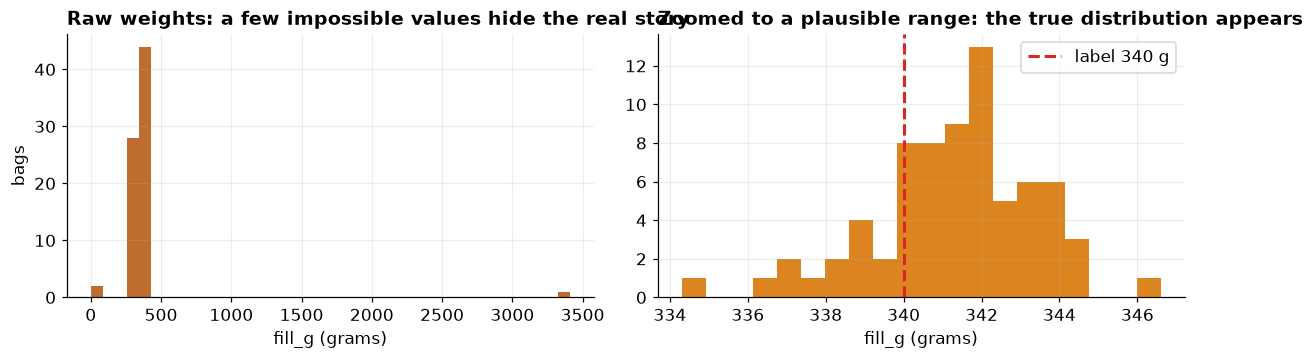

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(raw.fill_g.dropna(), bins=40, color=GOLD, alpha=0.85)
ax[0].set_title("Raw weights: a few impossible values hide the real story")
ax[0].set_xlabel("fill_g (grams)"); ax[0].set_ylabel("bags")
plaus = raw.fill_g[(raw.fill_g > 300) & (raw.fill_g < 380)]
ax[1].hist(plaus, bins=20, color=AMBER, alpha=0.9)
ax[1].axvline(TARGET, color=RD, lw=2, ls="--", label="label 340 g")
ax[1].set_title("Zoomed to a plausible range: the true distribution appears")
ax[1].set_xlabel("fill_g (grams)"); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 5 &middot; Prepare and clean
Three problems to fix, in order: **duplicate log rows**, **missing weights**, and **impossible values**. A valid net weight for a 340 g bag sits comfortably inside 300 to 380 g, so anything outside that range is a recording error, not a light or heavy bag. We remove them and keep a clean analysis sample.

In [5]:
before = len(raw)
df = raw.drop_duplicates()
after_dupes = len(df)
df = df.dropna(subset=["fill_g"])
after_na = len(df)
bad = df[(df.fill_g <= 300) | (df.fill_g >= 380)]
df = df[(df.fill_g > 300) & (df.fill_g < 380)].copy()
print(f"start rows          : {before}")
print(f"after drop_duplicates: {after_dupes}   (removed {before-after_dupes} duplicate rows)")
print(f"after dropna fill_g : {after_na}   (removed {after_dupes-after_na} blank weights)")
print("impossible values removed:", sorted(bad.fill_g.tolist()))
print(f"clean analysis sample: n = {len(df)}")

start rows          : 78
after drop_duplicates: 76   (removed 2 duplicate rows)
after dropna fill_g : 73   (removed 3 blank weights)
impossible values removed: [0.0, 34.1, 3410.0]
clean analysis sample: n = 70


In [6]:
x = df.fill_g.values
n = len(x)
mean, sd = x.mean(), x.std(ddof=1)
se = sd/np.sqrt(n)
print(f"n = {n}    mean = {mean:.3f} g    sd = {sd:.3f} g    se = {se:.3f} g")
print(f"observed gap from target: {mean-TARGET:+.3f} g")

n = 70    mean = 341.229 g    sd = 2.105 g    se = 0.252 g
observed gap from target: +1.229 g


## Step 6 &middot; Name the design
This is about as simple as a study design gets: **one sample of independent measurements, compared to a single fixed value** (the 340 g label). There are no groups and no pairing. That design plus a continuous outcome is exactly what the one-sample t-test is built for, provided its assumption holds.

## Step 7 &middot; Check the assumption
The one-sample t-test assumes the data are roughly **normal** (or that the sample is large enough for the Central Limit Theorem to carry it). We check three ways: the **Shapiro-Wilk** test, the **Kolmogorov-Smirnov** test, and a **Q-Q plot** by eye. The plot matters as much as the p-values.

Shapiro-Wilk : W = 0.973, p = 0.142   -> normal enough
Kolmogorov-Smirnov: D = 0.080, p = 0.735   -> normal enough
skew = -0.58   kurtosis = 1.01


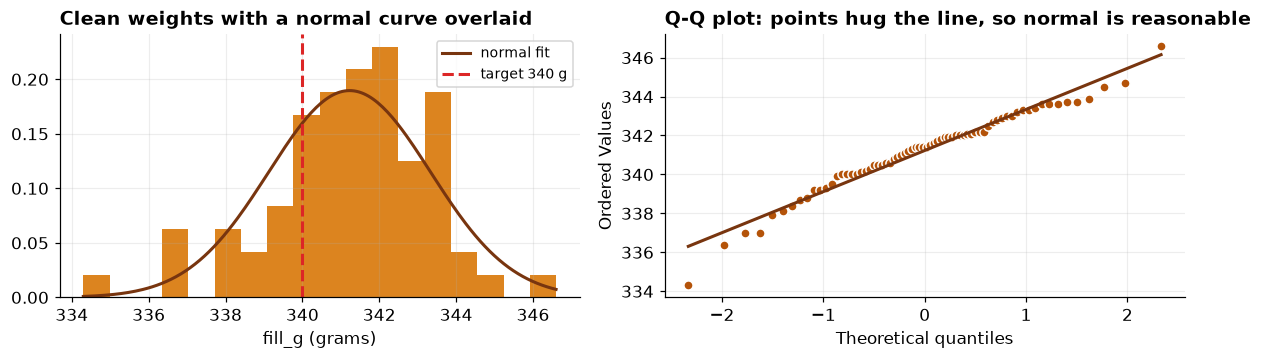

In [7]:
sw = stats.shapiro(x)
ks = stats.kstest(x, stats.norm(loc=mean, scale=sd).cdf)
print(f"Shapiro-Wilk : W = {sw.statistic:.3f}, p = {sw.pvalue:.3f}   -> {'normal enough' if sw.pvalue>0.05 else 'not normal'}")
print(f"Kolmogorov-Smirnov: D = {ks.statistic:.3f}, p = {ks.pvalue:.3f}   -> {'normal enough' if ks.pvalue>0.05 else 'not normal'}")
print(f"skew = {stats.skew(x):.2f}   kurtosis = {stats.kurtosis(x):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(x, bins=18, color=AMBER, alpha=0.9, density=True)
xs = np.linspace(x.min(), x.max(), 200)
ax[0].plot(xs, stats.norm.pdf(xs, mean, sd), color=DARK, lw=2, label="normal fit")
ax[0].axvline(TARGET, color=RD, lw=2, ls="--", label="target 340 g")
ax[0].set_title("Clean weights with a normal curve overlaid"); ax[0].set_xlabel("fill_g (grams)"); ax[0].legend(fontsize=9)
stats.probplot(x, dist="norm", plot=ax[1])
ax[1].get_lines()[0].set(marker="o", markerfacecolor=GOLD, markeredgecolor="white", markersize=6)
ax[1].get_lines()[1].set(color=DARK, lw=2)
ax[1].set_title("Q-Q plot: points hug the line, so normal is reasonable")
plt.tight_layout(); plt.show()

## Step 8 &middot; Decide, and fix if needed
Shapiro-Wilk and Kolmogorov-Smirnov both fail to reject normality, and the Q-Q points sit close to the straight line, so the normality assumption is satisfied. No transformation is needed. We proceed with the **parametric one-sample t-test**, and as a safety check we will also run its rank-based twin, the **Wilcoxon signed-rank test**, which does not assume normality. If the two disagreed, we would trust the rank-based one; here they will agree.

## Step 9 &middot; Choose the test
- **Primary:** one-sample t-test of the mean against 340 g (assumption met).
- **Robustness check:** Wilcoxon signed-rank test on the differences from 340 g.
- **Reported alongside:** Cohen's d (effect size) and the 95% confidence interval for the mean.

## Step 10 &middot; Run the test and report fully
We run the t-test with `scipy` and confirm it with `pingouin`, which reports the effect size, the confidence interval, and the achieved power in one table. Then the Wilcoxon cross-check.

In [8]:
t, p = stats.ttest_1samp(x, TARGET)
print(f"one-sample t-test:  t({n-1}) = {t:.3f},  p = {p:.2e}")

res = pg.ttest(x, TARGET)
print("\npingouin one-sample t-test:")
print(res[["T","dof","alternative","cohen_d","power"]].round(4).to_string(index=False))
ci = res["CI95"].iloc[0]
d  = float(res["cohen_d"].iloc[0])
print(f"\n95% CI for the mean fill weight: [{ci[0]:.2f}, {ci[1]:.2f}] g")
print(f"Cohen's d = {d:.3f}  ({'small' if d<0.5 else 'medium' if d<0.8 else 'large'} effect)")

w, pw = stats.wilcoxon(x - TARGET)
print(f"\nWilcoxon signed-rank (robustness): W = {w:.1f}, p = {pw:.2e}  -> same conclusion")

one-sample t-test:  t(69) = 4.884,  p = 6.47e-06

pingouin one-sample t-test:
     T  dof alternative  cohen_d  power
4.8841   69   two-sided   0.5838 0.9978

95% CI for the mean fill weight: [340.73, 341.73] g
Cohen's d = 0.584  (medium effect)

Wilcoxon signed-rank (robustness): W = 404.5, p = 7.50e-06  -> same conclusion


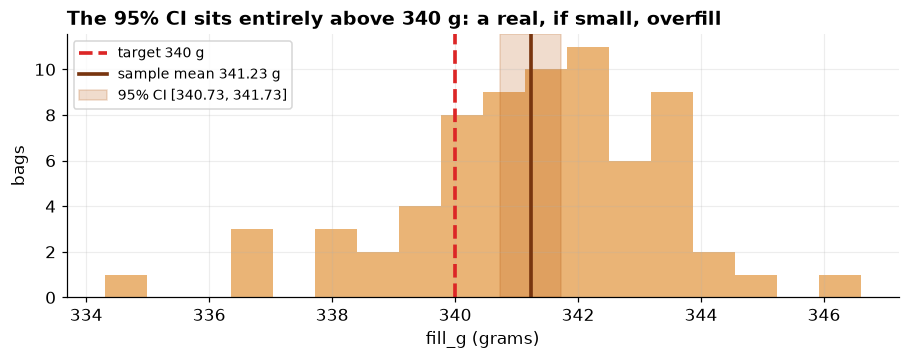

In [9]:
# The result in one picture: the sample mean and its 95% CI against the target.
tcrit = stats.t.ppf(0.975, n-1)
lo, hi = mean - tcrit*se, mean + tcrit*se
fig, ax = plt.subplots(figsize=(8.4, 3.4))
ax.hist(x, bins=18, color=AMBER, alpha=0.55)
ax.axvline(TARGET, color=RD, lw=2.4, ls="--", label=f"target {TARGET:.0f} g")
ax.axvline(mean, color=DARK, lw=2.4, label=f"sample mean {mean:.2f} g")
ax.axvspan(lo, hi, color=GOLD, alpha=0.20, label=f"95% CI [{lo:.2f}, {hi:.2f}]")
ax.set_title("The 95% CI sits entirely above 340 g: a real, if small, overfill")
ax.set_xlabel("fill_g (grams)"); ax.set_ylabel("bags"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Step 11 &middot; Estimate, do not just test
The p-value answered a yes-or-no question: are the bags filled to 340 g? They are not. It said nothing about **by how much**, and that is the only number the plant can act on. An interval answers the question the p-value ducks.

In [10]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

# 1. The overfill itself. The CI for the mean shifts straight onto the overfill scale.
overfill = mean - TARGET
over_lo, over_hi = lo - TARGET, hi - TARGET
print(f"overfill per bag       {overfill:+.2f} g    95% CI [{over_lo:+.2f}, {over_hi:+.2f}] g")

# 2. The same interval expressed as the thing a plant manager budgets for.
print(f"per million bags       {overfill*1000:,.0f} kg   95% CI [{over_lo*1000:,.0f}, {over_hi*1000:,.0f}] kg")

# 3. An interval for the effect size, which is almost always reported bare.
d_lo, d_hi, _ = boot_ci(x, lambda s: (s.mean() - TARGET) / s.std(ddof=1))
print(f"Cohen's d              {d:.2f}         95% CI [{d_lo:.2f}, {d_hi:.2f}]")

# 4. Margin of error: half the width of the interval for the mean.
print(f"\nmargin of error on the mean fill: +/- {(hi-lo)/2:.2f} g at 95% confidence")
print(f"to halve it we would need roughly {n*4} bags, since precision improves with the square root of n")

overfill per bag       +1.23 g    95% CI [+0.73, +1.73] g
per million bags       1,229 kg   95% CI [727, 1,730] kg


Cohen's d              0.58         95% CI [0.32, 0.94]

margin of error on the mean fill: +/- 0.50 g at 95% confidence
to halve it we would need roughly 280 bags, since precision improves with the square root of n


**What the intervals add.** The overfill is not "1.23 g". It is somewhere between about 0.7 and 1.7 g per bag, and every downstream figure inherits that width: the giveaway is between roughly 700 and 1,700 kg per million bags, not a precise 1,229. Quoting the point estimate alone would let a planner build a budget on a number the data cannot support to that precision.

**And the effect size gets an interval too.** Cohen's d of 0.58 comes with a 95% interval of roughly 0.32 to 0.94, which runs from "small" all the way to "large" in the conventional labels. That is worth knowing before anyone writes "a medium-sized effect" as though the category had been settled by the data.

## Step 12 &middot; Interpret in plain language
The mean fill weight is about **341.2 g**, and the test says that gap from 340 g is far too large to be chance (p is tiny). The 95% confidence interval, roughly **[340.7, 341.7] g**, lies entirely above the label, so we are confident the line runs **heavy, not light**. The effect size (Cohen's d near 0.6) is medium: the overfill is modest per bag, a bit over a gram, but it is consistent.

In [11]:
overfill = mean - TARGET
print(f"average overfill: {overfill:.2f} g per bag")
print(f"over a 1,000,000-bag run that is about {overfill*1_000_000/1000:,.0f} kg of extra coffee given away")
print("\nStatistically significant AND practically meaningful at scale,")
print("but every bag is still ABOVE the 340 g label, so no customer is shorted.")

average overfill: 1.23 g per bag
over a 1,000,000-bag run that is about 1,229 kg of extra coffee given away

Statistically significant AND practically meaningful at scale,
but every bag is still ABOVE the 340 g label, so no customer is shorted.


This is the honest, three-part read the framework asks for: a tiny **p-value** (chance is ruled out), a medium **effect size** (the overfill is real but modest per bag), and a **confidence interval** that says how precisely we know it. Significant and meaningful are not the same word, and here both happen to be true.

## Step 13 &middot; Ethics, bias, and limits
A clean result still deserves a skeptical last look.
- **Sampling:** the bags were pulled across lines and shifts in one day. If QC tends to sample when the machine is freshly calibrated, the true overfill could be understated. A conclusion about "the process" needs sampling that spans machine states, not one convenient window.
- **Measurement:** everything rides on the scale. A scale reading 0.5 g high would manufacture an overfill that is not there. Calibration against a certified weight is part of trusting this number.
- **Generalization:** this is one day on two lines. It supports a claim about that run, not a permanent property of the brand, until more days confirm it.
- **Use:** the safe and honest action is to nudge the target down toward roughly 340.5 g, saving coffee while staying comfortably above the legal minimum. Cutting straight to 340 g would push half of future bags below the label, which is exactly what the law forbids.

---
**From analysis to report.** The notebook produced the evidence: the cleaning trail, the assumption checks, the test, the effect size, and the interval. The companion **written report** turns that into a one-page memo a plant manager can act on, leading with the recommendation and keeping the statistics in plain language. Automate the evidence; author the argument.